In [1]:
# -------------------------------------------------------------------------
# Librerías
# -------------------------------------------------------------------------
library(stars)
library(dplyr)
library(sf)

# Ajuste de variables de entorno de GDAL
# Se incrementa el límite de bandas para permitir el procesamiento de cubos 5D 
# con una densidad temporal o vertical elevada (ej. ERA5 o modelos climáticos).
Sys.setenv(GDAL_MAX_BAND_COUNT = 1200000)

# -------------------------------------------------------------------------
# Rutas y nombres de archivos
# -------------------------------------------------------------------------

path     <- "./data_heavy/"
ncname   <- "download5Dcolombia"
ncfile5d <- paste0(path, ncname, ".nc")
zipfile  <- paste0(path, ncname, ".zip")

# -------------------------------------------------------------------------
# Control de existencia y descompresión de archivos
# -------------------------------------------------------------------------

if (!file.exists(ncfile5d)) {

  if (file.exists(zipfile)) {
    message("Descomprimiendo archivo...")
    unzip(zipfile, exdir = path)
  } else {
    stop("No existe .nc ni .zip")
  }

} else {
  message("Usando archivo existente")
}

# -------------------------------------------------------------------------
# Carga lazy
# -------------------------------------------------------------------------

# Lectura mediante proxy=TRUE para manipulación diferida (lazy evaluation).
# Esto permite definir recortes espaciales y temporales sin cargar todo el 
# archivo.
st_col5d = read_stars(ncfile5d, proxy=TRUE)

# Warning: dimension #1 (number) is not a Time dimension.
# Explicación: GDAL identifica "number" (ensamble) y aclara que no cumple 
# con los atributos CF de tiempo; se procesa como dimensión entera.

# Warning: The dataset has several variables that could be identified as vector fields...
# Explicación: Si hubiera vientos U/V, GDAL no los agrupa automáticamente por 
# discrepancias dimensionales; se cargan como atributos escalares.

# Chequeto de CRS
st_crs(st_col5d)

# Asignación de CRS en {stars}
# Opción 1: Asignación directa (reemplaza el NA en el objeto existente)
#st_crs(st_col5d) <- 4326
# Opción 2: Usando st_set_crs (estilo funcional/pipe)
st_col5d <- st_col5d %>% st_set_crs(4326)
#st_col5d <- st_set_crs(st_col5d, 4326)

cat("\n=== DATASET ===\n")
print(st_col5d)

# -------------------------------------------------------------------------
# Dimensiones
# -------------------------------------------------------------------------

cat("\n=== DIMENSIONES ===\n")
print(st_dimensions(st_col5d))

# -------------------------------------------------------------------------
# Variable
# -------------------------------------------------------------------------

cat("\n=== VARIABLES ===\n")
print(names(st_col5d))

# -------------------------------------------------------------------------
# Metadatos
# -------------------------------------------------------------------------

cat("\n=== METADATOS ===\n")
print(st_get_dimension_values(st_col5d, names(st_dimensions(st_col5d))[1]))

# (Nota: stars no expone attrs globales tan directo como xarray/Julia)

# -------------------------------------------------------------------------
# Forma
# -------------------------------------------------------------------------

cat("\n=== SHAPE ===\n")
print(dim(st_col5d))

# -------------------------------------------------------------------------
# Niveles
# -------------------------------------------------------------------------

niveles_presion <- st_get_dimension_values(st_col5d, "level")

cat("\nPrimeros niveles:\n")
print(head(niveles_presion, 2))

cat("\nÚltimos niveles:\n")
print(tail(niveles_presion, 2))

Loading required package: abind

Loading required package: sf

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Usando archivo existente

Warning message in CPL_get_metadata(file, NA_character_, options):
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: The dataset has several variables that could be identified as vector fields, but not all share the same primary dimension. Consequently they will be ignored.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”


Coordinate Reference System: NA


=== DATASET ===
stars_proxy object with 1 attribute in 1 file(s):
$download5Dcolombia.nc
[1] "[...]/download5Dcolombia.nc"

dimension(s):
       from  to                                      offset
x         1  25                                      -79.35
y         1  35                                       12.75
level     1  37                                          NA
number    1  10                                           0
time      1 480 1051896 [hours since 1900-01-01 00:00:00.0]
                                       delta  refsys
x                                        0.5  WGS 84
y                                       -0.5  WGS 84
level                                     NA udunits
number                                     1      NA
time   3 [hours since 1900-01-01 00:00:00.0] udunits
                                              values x/y
x                                               NULL [x]
y                                               NULL [y]
level  [1,2)

Warning message in CPL_get_metadata(file, NA_character_, options):
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: The dataset has several variables that could be identified as vector fields, but not all share the same primary dimension. Consequently they will be ignored.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”


stars object with 3 dimensions and 1 attribute
attribute(s):
                              Min.  1st Qu.   Median     Mean  3rd Qu.     Max.
download5Dcolombia.nc [K] 246.5078 251.7021 256.4746 257.2614 263.3567 265.8842
dimension(s):
      from to offset delta  refsys                               values x/y
x        1 25 -79.35   0.5  WGS 84                                 NULL [x]
y        1 35  12.75  -0.5  WGS 84                                 NULL [y]
level    1  2     NA    NA udunits [1,2) [millibars], [2,3) [millibars]    

Warning message in CPL_get_metadata(file, NA_character_, options):
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: The dataset has several variables that could be identified as vector fields, but not all share the same primary dimension. Consequently they will be ignored.”
Warning message in CPL_read_gdal(as.character(x), as.character(options), as.character(driver), :
“GDAL Message 1: dimension #1 (number) is not a Time dimension.”


stars object with 5 dimensions and 1 attribute
attribute(s):
                              Min. 1st Qu.   Median     Mean  3rd Qu.     Max.
download5Dcolombia.nc [K] 186.1205 226.303 259.9218 254.9801 288.8509 303.3165
dimension(s):
       from  to                                      offset
x        11  11                                      -79.35
y        16  17                                       12.75
level     1  37                                          NA
number    1  10                                           0
time      1 480 1051896 [hours since 1900-01-01 00:00:00.0]
                                       delta  refsys
x                                        0.5  WGS 84
y                                       -0.5  WGS 84
level                                     NA udunits
number                                     1      NA
time   3 [hours since 1900-01-01 00:00:00.0] udunits
                                              values x/y
x                               

stars object with 2 dimensions and 1 attribute
attribute(s):
                              Min.  1st Qu.  Median    Mean  3rd Qu.     Max.
download5Dcolombia.nc [K] 299.0198 299.1434 299.267 299.267 299.3906 299.5142
dimension(s):
  from to offset delta refsys x/y
x   11 11 -79.35   0.5 WGS 84 [x]
y   16 17  12.75  -0.5 WGS 84 [y]

Units: [K]
         [,1]     [,2]
[1,] 299.5142 299.0198
[1] "x" "y"
  from to offset delta refsys x/y
x   11 11 -79.35   0.5 WGS 84 [x]
y   16 17  12.75  -0.5 WGS 84 [y]
[1] -74.1
[1] 5.0 4.5
Valores en la dimensión x:  -74.0999984741211 
Valores en la dimensión y:  5, 4.5 


Loading required package: viridisLite

Resolución espacial baja. Renderizando matriz nativa sin unidades.



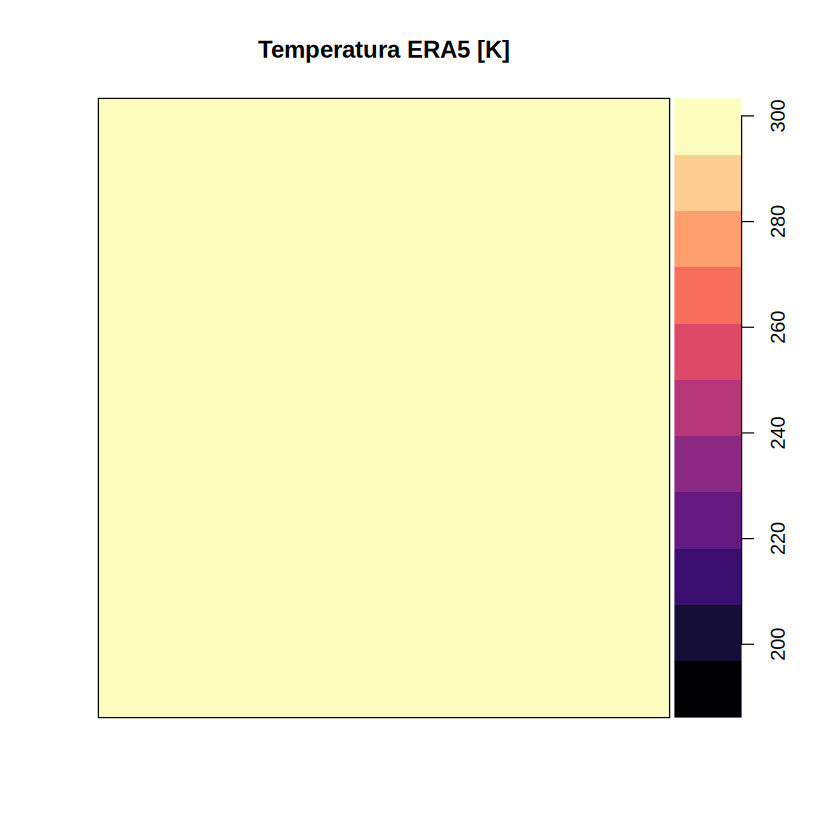

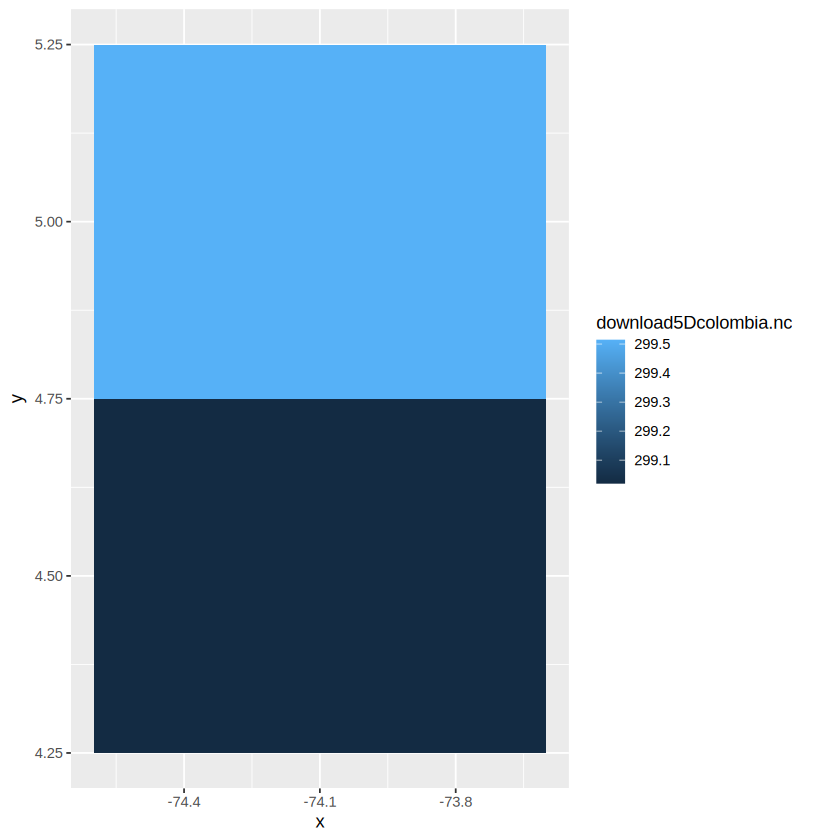

In [2]:
library(stars)
library(dplyr)
library(sf)
library(ggplot2)

# ============================================================
# Selección avanzada en cubo 5D (ERA5) con {stars}
# - Selección por dimensiones
# - Recorte espacial (Bogotá)
# - Extracción de variable
# - Reducción a slice 2D + Visualización
# ============================================================

# -------------------------------------------------------------------------
# Selección de atributos mediante indexación posicional
# -------------------------------------------------------------------------
# El filtrado se realiza sobre las dimensiones del cubo (atributos, x, y, level, number, time).
# st_as_stars() materializa el recorte en memoria tras la selección.
# pero la indexación posicional no funciona, porque internamente
# el orden de las dimensiones puede ser diferente a como se despliega en el objeto stars
# mySel1 <- st_as_stars(st_col5d[         , 1:25,   1:35,   1:2,      1, 1   ])
# mySel1 <- st_as_stars(st_col5d[ atributo,    x,      y, level, number, time])
# mySel1 <- st_as_stars(st_col5d[,1:25,1:35,1:2,1,1])


# Simplificación de la estructura
# adrop() elimina dimensiones unitarias (longitud 1) generadas tras la selección.
# mySel1 <- mySel1 %>% adrop()

# -------------------------------------------------------------------------
# Selección 1: Subconjunto por dimensiones.
#              Mediante verbos de dplyr.
# -------------------------------------------------------------------------
# Selecciona:
# - niveles 1 y 2
# - miembro de ensamble 1
# - tiempo 1

sel_dim <- st_col5d %>% 
  slice(level, 1:2) %>% 
  slice(number, 1) %>% 
  slice(time, 1)

# Materializa en memoria
sel_dim <- st_as_stars(sel_dim)
sel_dim


# -------------------------------------------------------------------------
# Selección 2: Recorte espacial (Bogotá)
# -------------------------------------------------------------------------
# Bounding box en WGS84

bog_bbox <- st_bbox(
  c(xmin = -74.25, ymin = 4.45,
    xmax = -73.90, ymax = 4.85),
  crs = st_crs(4326)
)

# Recorte espacial sobre el proxy
# Nota: Ambos objetos deben tener el mismo CRS
sel_bogota <- st_crop(st_col5d, bog_bbox)
sel_bogota <- st_as_stars(sel_bogota)
sel_bogota


# -------------------------------------------------------------------------
# Slice 2D
# -------------------------------------------------------------------------
# Selecciona:
# - último nivel
# - ensamble 1
# - tiempo 1

capa_2d <- sel_bogota %>%
  slice(level, length(st_get_dimension_values(st_col5d, "level"))) %>%
  slice(number, 1) %>%
  slice(time, 1) %>%
  adrop() # borra dimensiones unitarias

capa_2d


# Alternativa mediante indexación de atributos
print(capa_2d[[1]])

# Verificación de las dimensiones restantes (nombres)
print(names(st_dimensions(capa_2d)))

# Verificación de los valores de las coordenadas y metadatos completos
print(st_dimensions(capa_2d))

# Extracción de los valores de longitud (x) y latitud (y)
# Se asume que las dimensiones se llaman "x" e "y" tras el procesamiento
eje_x <- st_get_dimension_values(capa_2d, "x")
eje_y <- st_get_dimension_values(capa_2d, "y")

print(eje_x)
print(eje_y)

# Verificación y extracción robusta
dimensiones_nombres <- names(st_dimensions(capa_2d))

for (dim in dimensiones_nombres) {
  valores <- st_get_dimension_values(capa_2d, dim)
  cat(paste0("Valores en la dimensión ", dim, ": "), paste(valores, collapse = ", "), "\n")
}

# -------------------------------------------------------------------------
# Plot simple según tamaño del objeto stars
# -------------------------------------------------------------------------

# -------------------------------------------------------------------------
# Control de renderizado para resolución espacial baja y variables con unidades
# -------------------------------------------------------------------------
library(viridis)

# 1. Recuperar dimensiones
dim_x <- dim(capa_2d)["x"]
dim_y <- dim(capa_2d)["y"]

if (dim_x >= 2 && dim_y >= 2) {
  
  plot(capa_2d[1], 
       main = "Temperatura ERA5 - Bogotá [K]", 
       col = paleta_colores, 
       breaks = cortes_leyenda, 
       key.pos = 4)
       
} else {
  
  message("Resolución espacial baja. Renderizando matriz nativa sin unidades.")
  
  # -------------------------------------------------------------------------
  # Control de renderizado de matriz nativa aplicando el rango global
  # -------------------------------------------------------------------------
  library(viridis)
    
  # 1. Definir rango global (del stars original sel_bogota)
  rango_global <- range(sel_bogota[[1]], na.rm = TRUE)
    
  # 2. Remover la clase 'units' (ej. [K]) para evitar conflictos con image() nativo
  rango_num <- as.numeric(rango_global)
    
  # 3. Extraer valores y asegurar estructura de matriz puramente numérica
  matriz_valores <- as.numeric(drop(capa_2d[[1]]))
  matriz_valores <- matrix(matriz_valores, nrow = dim_x, ncol = dim_y)
    
  # 4. Configurar la paleta de colores
  paleta_colores <- viridis::magma(11)
    
  # Dividir la ventana gráfica: 80% para el mapa, 20% para la leyenda
  layout(matrix(1:2, ncol = 2), widths = c(4, 1))
    
  # --- PANEL 1: MAPA ---
  par(mar = c(5, 4, 4, 0) + 0.1)
    
  # Se utiliza zlim = rango_num para obligar a que los colores de la matriz 
  # se mapeen estrictamente dentro del rango global, no del local.
  image(z = matriz_valores, 
        main = "Temperatura ERA5 [K]", 
        col = paleta_colores, 
        zlim = rango_num, 
        axes = FALSE)
  box()
    
  # --- PANEL 2: LEYENDA ---
  par(mar = c(5, 0, 4, 4) + 0.1)
    
  # Se construye el eje de la leyenda basándose en el rango global numérico
  eje_leyenda <- seq(rango_num[1], rango_num[2], length.out = length(paleta_colores) + 1)
    
  image(x = 1, 
        y = eje_leyenda, 
        z = t(as.matrix(eje_leyenda[-1])), 
        col = paleta_colores, 
        zlim = rango_num, 
        axes = FALSE, 
        xlab = "", 
        ylab = "")
    
  # Añadir los valores del rango global en el eje derecho
  axis(4) 
    
  # Restaurar la configuración de la ventana gráfica
  layout(1)
  par(mar = c(5, 4, 4, 2) + 0.1)
}

ggplot() +
  # geom_stars extrae automáticamente las coordenadas y el valor del píxel
  geom_stars(data = capa_2d)

In [3]:
print(capa_2d[[1]])

Units: [K]
         [,1]     [,2]
[1,] 299.5142 299.0198
